In [1]:
import openpyxl
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.util import bigrams
import csv
import re
from itertools import islice
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk import word_tokenize, bigrams
from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
nltk.download('punkt')
# Download das stopwords em português se ainda não estiverem baixadas
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\carlo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\carlo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\carlo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
caminho_termos_chave = './data_input/termos_chaves/sbert.xlsx'
caminho_cluster_0 = './data_input/clusters/Oct_2022_cluster_0.csv'
caminho_cluster_1 = './data_input/clusters/Oct_2022_cluster_1.csv'
textos_encontrados_cluster_0 = './resultados/cluster_0/1_bigrama_tfidf_cluster_0.xlsx'
textos_encontrados_cluster_1 = './resultados/cluster_1/1_bigrama_tfidf_cluster_1.xlsx'

In [3]:
def procurar_e_imprimir(textos, termos):
    nltk.download('punkt')
    resultados = {termo: [] for termo in termos}
    textos_utilizados = set()

    for termo in termos:
        bigramas_termo = list(bigrams(termo.lower().split()))
        textos_encontrados = 0

        for texto in textos:
            if texto['text'] in textos_utilizados:
                continue

            texto_lower = texto['text'].lower()
            palavras_texto = word_tokenize(texto_lower)
            bigramas_texto = list(bigrams(palavras_texto))
            count = sum(1 for bigrama in bigramas_termo if bigrama in bigramas_texto)

            if count >= 1:  # Verifica se pelo menos 1 bigramas do termo estão no texto
                texto['correspondencia'] = count
                resultados[termo].append(texto)
                textos_utilizados.add(texto['text'])
                textos_encontrados += 1

    return resultados

In [ ]:
def main():
    # Carregar termos da coluna da planilha .xlsx
    # wb = openpyxl.load_workbook('../PGC_fact_check/resultados/arquivo_limpo.xlsx')
    wb = openpyxl.load_workbook(caminho_termos_chave)
    planilha = wb['Sheet1']

    # Extrair termos-chave da coluna 'Termos_chave' (coluna F)
    termos = [celula.value for celula in planilha['F'] if celula.value]

    # Carregar textos da coluna 'text' do arquivo CSV e remover duplicatas
    with open(caminho_cluster_0, 'r', encoding='utf-8') as arquivo:
        leitor_csv = csv.DictReader(arquivo)
        textos = [{key: row[key] for key in row} for row in leitor_csv if row['text']]

    # Procurar e imprimir textos relevantes para cada termo
    resultados = procurar_e_imprimir(textos, termos)

    # Criar lista de dicionários para os resultados
    lista_resultados = []
    for termo, textos_relevantes in resultados.items():
        for texto in textos_relevantes:
            texto['termo'] = termo
            lista_resultados.append(texto)

    # Criar DataFrame a partir da lista de dicionários
    df_resultados = pd.DataFrame(lista_resultados)

    # Salvar os resultados em um arquivo Excel
    df_resultados.to_excel(textos_encontrados_cluster_0, index=False)

    print('Resultados salvos com sucesso.')

if __name__ == "__main__":
    main()

[nltk_data] Downloading package punkt to C:\Users\carlo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Resultados salvos com sucesso.


In [ ]:
def main():
    # Carregar termos da coluna da planilha .xlsx
    # wb = openpyxl.load_workbook('../PGC_fact_check/resultados/arquivo_limpo.xlsx')
    wb = openpyxl.load_workbook(caminho_termos_chave)
    planilha = wb['Sheet1']
    
    # Extrair termos-chave da coluna 'Termos_chave' (coluna F)
    termos = [celula.value for celula in planilha['F'] if celula.value]

    # Carregar textos da coluna 'text' do arquivo CSV e remover duplicatas
    with open(caminho_cluster_1, 'r', encoding='utf-8') as arquivo:
        leitor_csv = csv.DictReader(arquivo)
        textos = [{key: row[key] for key in row} for row in leitor_csv if row['text']]

    # Procurar e imprimir textos relevantes para cada termo
    resultados = procurar_e_imprimir(textos, termos)

    # Criar lista de dicionários para os resultados
    lista_resultados = []
    for termo, textos_relevantes in resultados.items():
        for texto in textos_relevantes:
            texto['termo'] = termo
            lista_resultados.append(texto)

    # Criar DataFrame a partir da lista de dicionários
    df_resultados = pd.DataFrame(lista_resultados)

    # Salvar os resultados em um arquivo Excel
    df_resultados.to_excel(textos_encontrados_cluster_1, index=False)

    print('Resultados salvos com sucesso.')

if __name__ == "__main__":
    main()

[nltk_data] Downloading package punkt to C:\Users\carlo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Resultados salvos com sucesso.


In [6]:
def contar_termos_com_desinformacao(df):
    # Filtrar apenas os textos com desinformação
    df_desi_texts = df[df['desinformacao'].str.lower() == 'sim']
    
    # Contar a frequência dos termos nos textos com desinformação
    termo_counts = df_desi_texts['termo'].value_counts()
    
    return termo_counts

In [7]:
def load_excel(file_path, sheet_name):
    labeled_data = pd.read_excel(file_path, sheet_name=sheet_name)
    return labeled_data

# Função para carregar os dados não rotulados de um arquivo CSV
def load_csv(file_path):
    unlabeled_data = pd.read_csv(file_path)
    return unlabeled_data

# Função para rotular os textos não rotulados usando similaridade de cosseno
def label_unlabeled_data(unlabeled_data, labeled_data, vectorizer, threshold=0.9):
    X_unlabeled_tfidf = vectorizer.transform(unlabeled_data['text'])
    X_labeled_tfidf = vectorizer.transform(labeled_data['text'])
    labels = []
    similarities = []
    similar_terms = []

    for i in range(X_unlabeled_tfidf.shape[0]):
        similarity_scores = cosine_similarity(X_unlabeled_tfidf[i], X_labeled_tfidf)
        max_similarity = similarity_scores.max()
        similarities.append(max_similarity)

        if max_similarity > threshold:
            similar_doc_index = similarity_scores.argmax()
            labels.append(labeled_data.iloc[similar_doc_index]['desinformacao'])
            similar_terms.append(labeled_data.iloc[similar_doc_index]['Termos_chave'])  # Pega o termo associado
        else:
            labels.append(-1)
            similar_terms.append(None)

    return labels, similarities, similar_terms

In [8]:
caminho_cluster_0_rotulado = './resultados/rotulado/Oct_2022_cluster_0_labeled_sbert.xlsx'
caminho_cluster_1_rotulado = './resultados/rotulado/Oct_2022_cluster_1_labeled_sbert.xlsx'

In [9]:
# Carregar os dados rotulados e não rotulados
labeled_data = load_excel('./data_input/texto_encontrados_out_2022.xlsx', 'Cluster_1')
unlabeled_data = load_excel(textos_encontrados_cluster_1, 'Sheet1')

# Vetorizar os textos rotulados com TF-IDF
vectorizer = TfidfVectorizer().fit(labeled_data['text'])

# Rotular os textos não rotulados e obter as similaridades e termos
labels, similarities, similar_terms = label_unlabeled_data(unlabeled_data, labeled_data, vectorizer)

# Adicionar os rótulos, similaridades e termos ao DataFrame não rotulado
unlabeled_data['desinformacao'] = labels
unlabeled_data['similaridade'] = similarities
unlabeled_data['termo_similar'] = similar_terms

# Salvar todos os dados rotulados e não rotulados em um novo Excel
output_path = caminho_cluster_1_rotulado
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    unlabeled_data.to_excel(writer, sheet_name='Rotulados', index=False)

# Filtrar os dados que não foram rotulados (-1)
unlabeled_unlabeled = unlabeled_data[unlabeled_data['desinformacao'] == -1]

# Salvar os dados não rotulados em uma aba separada
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    unlabeled_data.to_excel(writer, sheet_name='Rotulados', index=False)
    unlabeled_unlabeled.to_excel(writer, sheet_name='Não Rotulados', index=False)

print(f"Dados salvos em: {output_path}")

Dados salvos em: ./resultados/rotulado/Oct_2022_cluster_1_labeled_sbert.xlsx


In [10]:
# Carregar os dados rotulados e não rotulados
labeled_data = load_excel('data_input/texto_encontrados_out_2022.xlsx', 'Cluster_0')
unlabeled_data = load_excel(textos_encontrados_cluster_0, 'Sheet1')

# Vetorizar os textos rotulados com TF-IDF
vectorizer = TfidfVectorizer().fit(labeled_data['text'])

# Rotular os textos não rotulados e obter as similaridades e termos
labels, similarities, similar_terms = label_unlabeled_data(unlabeled_data, labeled_data, vectorizer)

# Adicionar os rótulos, similaridades e termos ao DataFrame não rotulado
unlabeled_data['desinformacao'] = labels
unlabeled_data['similaridade'] = similarities
unlabeled_data['termo_similar'] = similar_terms

# Salvar todos os dados rotulados e não rotulados em um novo Excel
output_path = caminho_cluster_0_rotulado
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    unlabeled_data.to_excel(writer, sheet_name='Rotulados', index=False)

# Filtrar os dados que não foram rotulados (-1)
unlabeled_unlabeled = unlabeled_data[unlabeled_data['desinformacao'] == -1]

# Salvar os dados não rotulados em uma aba separada
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    unlabeled_data.to_excel(writer, sheet_name='Rotulados', index=False)
    unlabeled_unlabeled.to_excel(writer, sheet_name='Não Rotulados', index=False)

print(f"Dados salvos em: {output_path}")

Dados salvos em: ./resultados/rotulado/Oct_2022_cluster_0_labeled_sbert.xlsx


In [11]:
def main():
    # Carregar dados de desinformação
    # df_desi = pd.read_excel('./resultados/rotulado/Oct_2022_cluster_0_labeled.xlsx', sheet_name='Rotulados')
    df_desi = pd.read_excel(caminho_cluster_0_rotulado, sheet_name='Rotulados')
    
    # Contar os termos que possuem "sim" na coluna desinformacao
    termo_counts = contar_termos_com_desinformacao(df_desi)
    
    # Ordenar e selecionar os top 5 termos mais frequentes
    top_5_termos = termo_counts.head(5)
    
    # Exibir os 5 termos mais frequentes com desinformação
    for termo, count in top_5_termos.items():
        print(f"Termo: {termo}, Quantidade de Desinformação: {count}")

if __name__ == "__main__":
    main()

Termo: aos fatosf: compartilhe é falso que o tse (tribunal superior eleitoral) não testou a segurança das urnas para as eleições de 2022 ou que as vulnerabilidades encontradas no sistema em 2012 ainda não foram corrigidas, como afirmam postagens (veja aqui). a alegação enganosa se baseia em um vídeo gravado em 2014 em que diego aranha, professor assistente de segurança de sistemas na universidade de aarhus, na dinamarca, anuncia o projeto você fiscal, mas os problemas citados por ele na gravação já foram sanados pela justiça eleitoral. o ano de 2014 não é mencionado no vídeo, mas há indícios de que a gravação foi feita naquela época: a expressão “eleições 2014” aparece aos 35’’ (veja abaixo) e aos 1’41’’ do vídeo. as fases anteriores que envolvem o software de votação continuam com limitações importantes de transparência”. criado em 2014 com a proposta de fiscalizar o resultado das eleições por meio da análise de fotos dos bus (boletins de urna) enviados por usuários, o você fiscal fun

In [12]:
def main():
    # Carregar dados de desinformação
    df_desi = pd.read_excel(caminho_cluster_1_rotulado, sheet_name='Rotulados')
    
    # Imprimir textos com maior correspondência (coluna correspondencia)
    top_textos = df_desi.sort_values(by='correspondencia', ascending=False).head(5)
    print("\nTextos com Maior Correspondência:")
    for idx, row in top_textos.iterrows():
        print(f"Texto: {row['text']}, Correspondência: {row['correspondencia']}")
        
        # Calcular a média da correspondência dos top textos
    media_correspondencia = top_textos['correspondencia'].mean()
    print(f"\nMédia da Correspondência dos Top Textos: {media_correspondencia}")
    
    # Calcular a média da correspondência de todos os textos
    media_correspondencia = df_desi['correspondencia'].mean()
    print(f"\nMédia da Correspondência de Todos os Textos: {media_correspondencia}")

if __name__ == "__main__":
    main()


Textos com Maior Correspondência:
Texto: @NonaConta_ @tovaga @ArthurLira_ ⚡⚡⚡    🌎  🌍  🌏    ⚡⚡⚡

- Este elemento não é digno das Alagoas.
Acaba de mudar de ideia e vai mandar pra o plenário da CÂMARA FEDERAL,  voto auditavel para as eleições de 2022.
Porque ele mudou de ideia?
O que ele tratou no encontro com Lex Luthor e o Fakin?
O quê?

⚡ https://t.co/6B9xcoUsun, Correspondência: 6
Texto: "Ele fala por indignação, por momento. Mas o presidente, pelo q estive com ele, é uma pessoa q respeita as instituições"

E olha q o presidente meteu um desfile de tanques constrangedores no dia da votação do voto impresso em frente ao congresso, isso q é respeito ás instituições https://t.co/0qibQlx9cZ, Correspondência: 6
Texto: A quem assustam bolsonaristas c/ suas mensagens tresloucadas nas redes?! Querem semear pânico. Isso está igual a live do Bolsonaro p/ mostrar fraude na urna eletrônica. A montanha pariu um rato. Ainda q as ruas estejam cheias deles no dia 7, serão somente eles. Seu núcleo 

In [13]:
def criar_grafico_desinformacao(df_cluster, df_desi, ax, titulo, labels):
    # Filtrar textos únicos no cluster
    df_cluster_unique = df_cluster.drop_duplicates(subset='text')
    
    # Inicializar contadores
    total_textos = df_cluster_unique.shape[0]
    desinformacao_count = 0
    nao_rotulado_count = 0
    
    # Iterar sobre os textos únicos no cluster
    df_merged = df_cluster_unique.merge(df_desi[['text', 'desinformacao']], on='text', how='left')

    df_merged['desinformacao_norm'] = df_merged['desinformacao'].str.strip().str.lower()

    desinformacao_count = (df_merged['desinformacao_norm'] == 'sim').sum()
    nao_rotulado_count = df_merged['desinformacao_norm'].isna().sum()

    # Calcular a porcentagem de desinformação
    total_rotulado = total_textos - nao_rotulado_count
    porcentagem_desinformacao = (desinformacao_count / total_rotulado) * 100 if total_rotulado > 0 else 0
    
    # Criar gráfico de pizza
    sizes = [desinformacao_count, total_rotulado - desinformacao_count, nao_rotulado_count]
    colors = ['#ff9999', '#66b3ff', '#c2c2c2']
    explode = (0.1, 0, 0)  # Explode 1st slice
    
    ax.pie(sizes, explode=explode, labels=labels, colors=colors,
           autopct=lambda p: f'{p:.1f}% ({int(p * total_textos / 100):d})', shadow=True, startangle=140)
    ax.set_title(titulo)

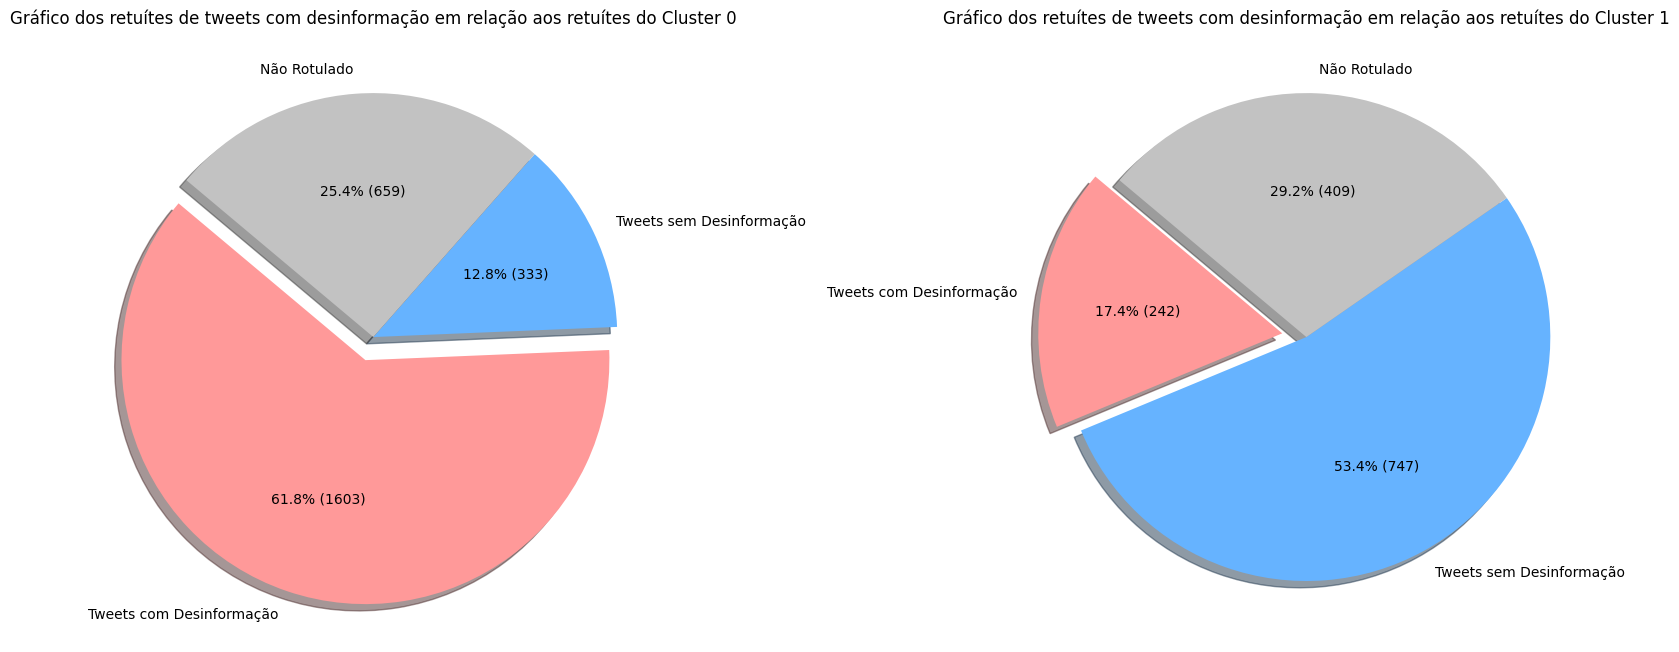

In [14]:
def main():
    labels = ['Tweets com Desinformação', 'Tweets sem Desinformação', 'Não Rotulado']
    
    # Carregar CSV de textos encontrados e desinformação
    df_cluster_0 = pd.read_csv(caminho_cluster_0)
    df_cluster_1 = pd.read_csv(caminho_cluster_1)
    
    # Carregar dados de desinformação
    df_desi_0 = pd.read_excel(caminho_cluster_0_rotulado, sheet_name='Rotulados')
    df_desi_1 = pd.read_excel(caminho_cluster_1_rotulado, sheet_name='Rotulados')
    
    # Criar figura e eixos para subplots
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    
    # Criar gráficos
    criar_grafico_desinformacao(df_cluster_0, df_desi_0, axs[0], 'Gráfico dos retuítes de tweets com desinformação em relação aos retuítes do Cluster 0', labels)
    criar_grafico_desinformacao(df_cluster_1, df_desi_1, axs[1], 'Gráfico dos retuítes de tweets com desinformação em relação aos retuítes do Cluster 1', labels)

    # Mostrar os gráficos
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

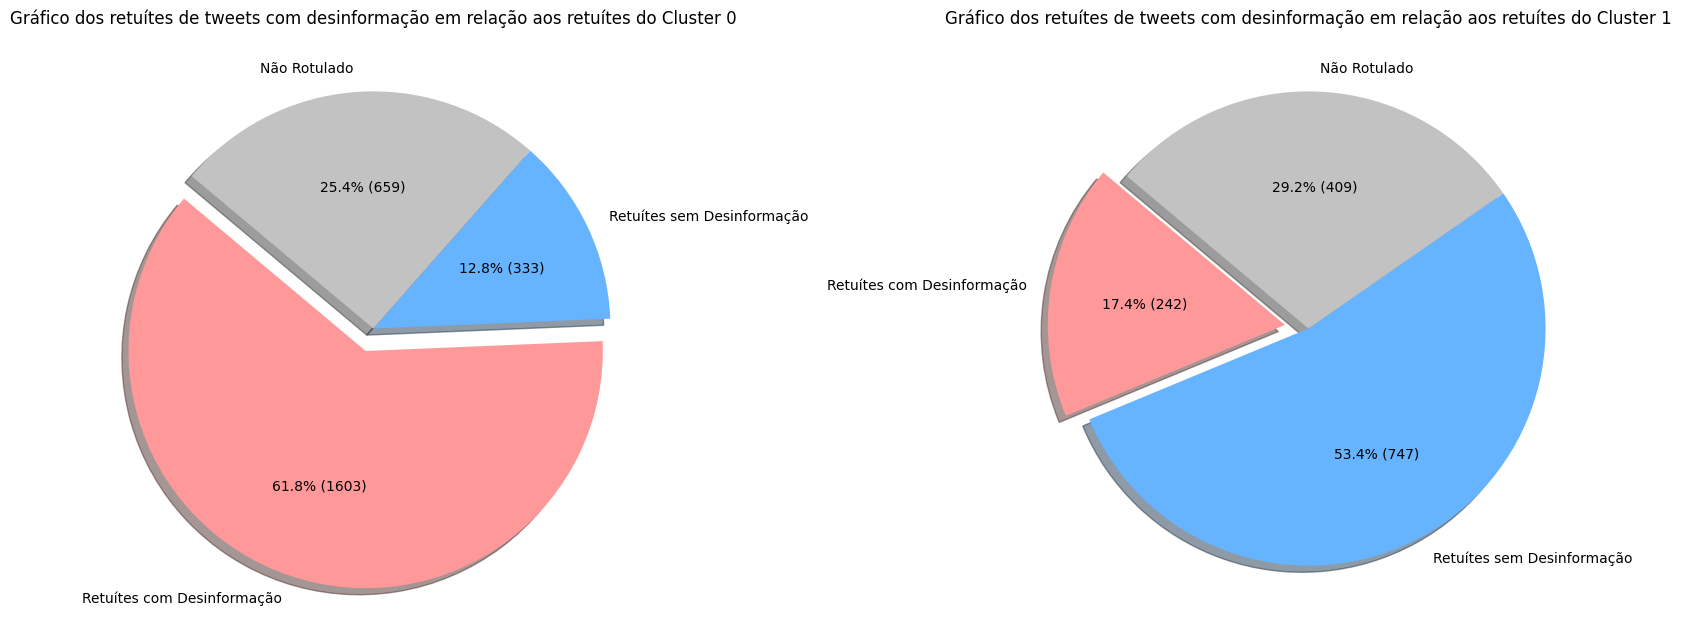

In [15]:
def main():
    labels = ['Retuítes com Desinformação', 'Retuítes sem Desinformação', 'Não Rotulado']
    # Carregar CSV de textos encontrados e desinformação
    df_cluster_0 = pd.read_csv(caminho_cluster_0)
    df_cluster_1 = pd.read_csv(caminho_cluster_1)
    
    # Carregar dados de desinformação
    df_desi_0 = pd.read_excel(caminho_cluster_0_rotulado, sheet_name='Rotulados')
    df_desi_1 = pd.read_excel(caminho_cluster_1_rotulado, sheet_name='Rotulados')
    
    # Criar figura e eixos para subplots
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    
    # Criar gráficos

    criar_grafico_desinformacao(df_cluster_0, df_desi_0, axs[0], 'Gráfico dos retuítes de tweets com desinformação em relação aos retuítes do Cluster 0', labels)
    criar_grafico_desinformacao(df_cluster_1, df_desi_1, axs[1], 'Gráfico dos retuítes de tweets com desinformação em relação aos retuítes do Cluster 1', labels)
    # Mostrar os gráficos
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


In [16]:
def criar_grafico_perfis_desinformacao(df_cluster, df_desi):
    # Identificar textos com desinformação (considerando todas as ocorrências)
    df_desi_texts = df_desi[df_desi['desinformacao'].str.lower() == 'sim']
    textos_com_desi = df_desi_texts['text']
    
    # Filtrar apenas os textos com desinformação
    df_desi_texts_cluster = df_cluster[df_cluster['text'].isin(textos_com_desi)]
    
    # Contar a frequência dos perfis em textos com desinformação
    perfil_counts = df_desi_texts_cluster['rtfrom'].value_counts().head(10)
    
    # Calcular porcentagens em relação ao total
    total = perfil_counts.sum()
    porcentagens = (perfil_counts / total) * 100
    
    # Criar gráfico de barras com porcentagens
    plt.figure(figsize=(14, 10))
    bars = perfil_counts.plot(kind='bar', color='red')
    
    # Adicionar rótulos com as porcentagens
    for i, v in enumerate(perfil_counts):
        pct = porcentagens.iloc[i]
        plt.text(i, v + 1, f'{pct:.1f}%', ha='center', fontsize=12)
    
    plt.title('Perfis com Mais Desinformação', fontsize=20)
    plt.xlabel('Perfil', fontsize=16)
    plt.ylabel('Quantidade de Desinformação', fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()

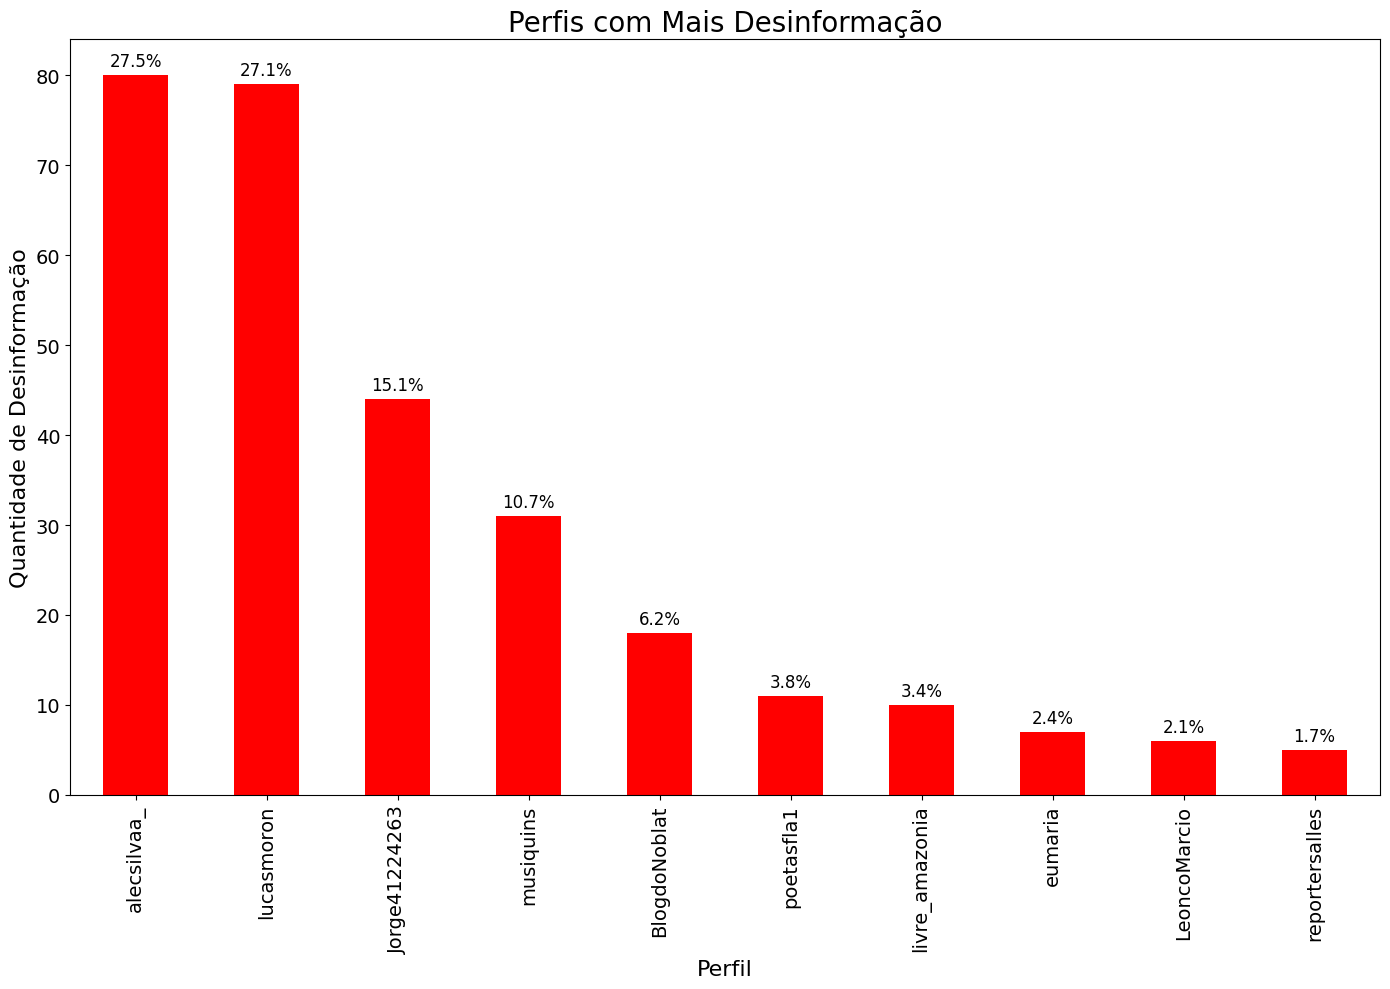

In [17]:
def main():
    # Carregar CSV de textos encontrados e desinformação (substitua pelo seu caminho real)
    df_cluster = pd.read_csv(caminho_cluster_1)
    
    # Carregar dados de desinformação (substitua pelo seu caminho real)
    df_desi = pd.read_excel(caminho_cluster_1_rotulado, sheet_name='Rotulados')
    
    # Criar gráfico de perfis com mais desinformação
    criar_grafico_perfis_desinformacao(df_cluster, df_desi)

if __name__ == "__main__":
    main()


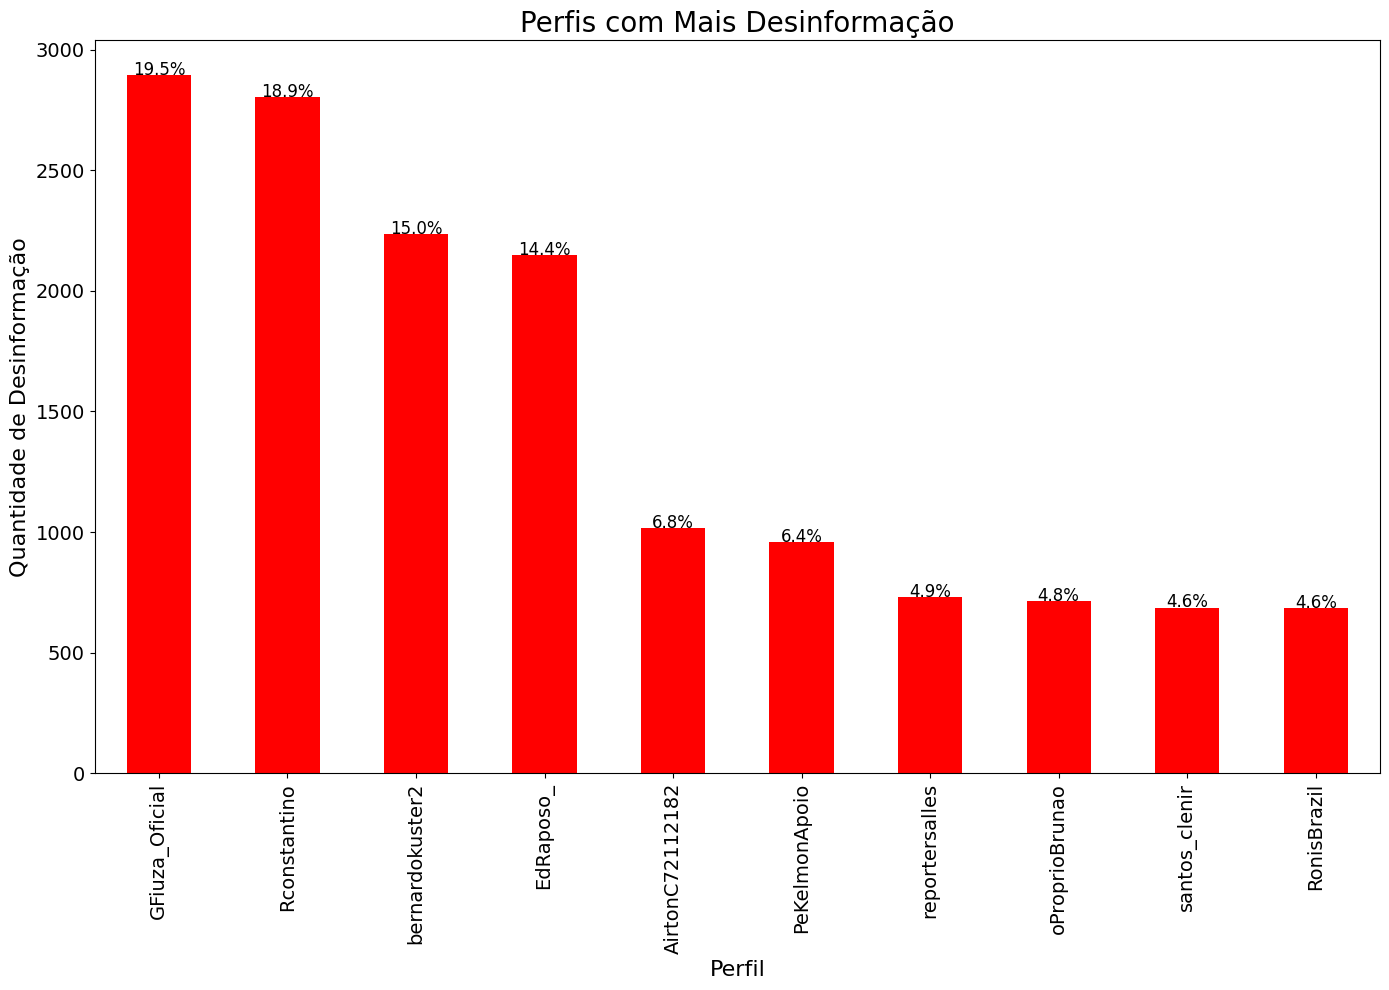

In [18]:
def main():
    # Carregar CSV de textos encontrados e desinformação (substitua pelo seu caminho real)
    df_cluster = pd.read_csv(caminho_cluster_0)
    
    # Carregar dados de desinformação (substitua pelo seu caminho real)
    df_desi = pd.read_excel(caminho_cluster_0_rotulado, sheet_name='Rotulados')
    
    # Criar gráfico de perfis com mais desinformação
    criar_grafico_perfis_desinformacao(df_cluster, df_desi)

if __name__ == "__main__":
    main()


In [19]:
def criar_grafico_perfis_desinformacao_unico(df_cluster, df_desi):
    # Filtrar textos únicos no cluster
    df_cluster_unique = df_cluster.drop_duplicates(subset='text')
    
    # Inicializar lista de textos com desinformação
    textos_com_desi = []
    
    # Adicionar todos os textos da planilha com desinformação 'sim'
    for text in df_cluster_unique['text']:
        if df_desi[(df_desi['text'] == text) & (df_desi['desinformacao'].str.lower() == 'sim')].shape[0] > 0:
            textos_com_desi.append(text)
    
    # Filtrar apenas os textos com desinformação
    df_desi_texts = df_cluster_unique[df_cluster_unique['text'].isin(textos_com_desi)]
    
    # Contar a frequência dos perfis em textos com desinformação
    perfil_counts = df_desi_texts['rtfrom'].value_counts().head(10)
    
    # Calcular porcentagens em relação ao total
    total = perfil_counts.sum()
    porcentagens = (perfil_counts / total) * 100
    
    # Criar gráfico de barras com porcentagens
    plt.figure(figsize=(10, 6))
    bars = perfil_counts.plot(kind='bar', color='red')
    
    # Adicionar rótulos com as porcentagens
    for i, v in enumerate(perfil_counts):
        pct = porcentagens.iloc[i]
        plt.text(i, v + 1, f'{pct:.1f}%', ha='center', fontsize=12)
    
    plt.title('Perfis com Mais Desinformação')
    plt.xlabel('Perfil')
    plt.ylabel('Quantidade de Desinformação')
    plt.show()

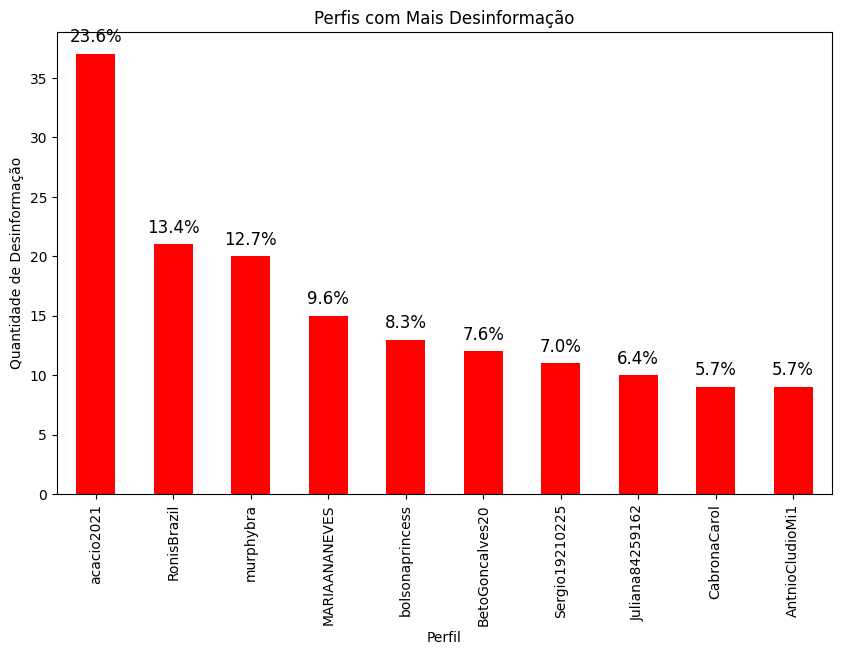

In [20]:
def main():
    # Carregar CSV de textos encontrados e desinformação
    df_cluster = pd.read_csv(caminho_cluster_0)
    
    # Carregar dados de desinformação (substitua pelo seu caminho real)
    df_desi = pd.read_excel(caminho_cluster_0_rotulado, sheet_name='Rotulados')
    
    # Criar gráfico de perfis com mais desinformação
    criar_grafico_perfis_desinformacao_unico(df_cluster, df_desi)

if __name__ == "__main__":
    main()

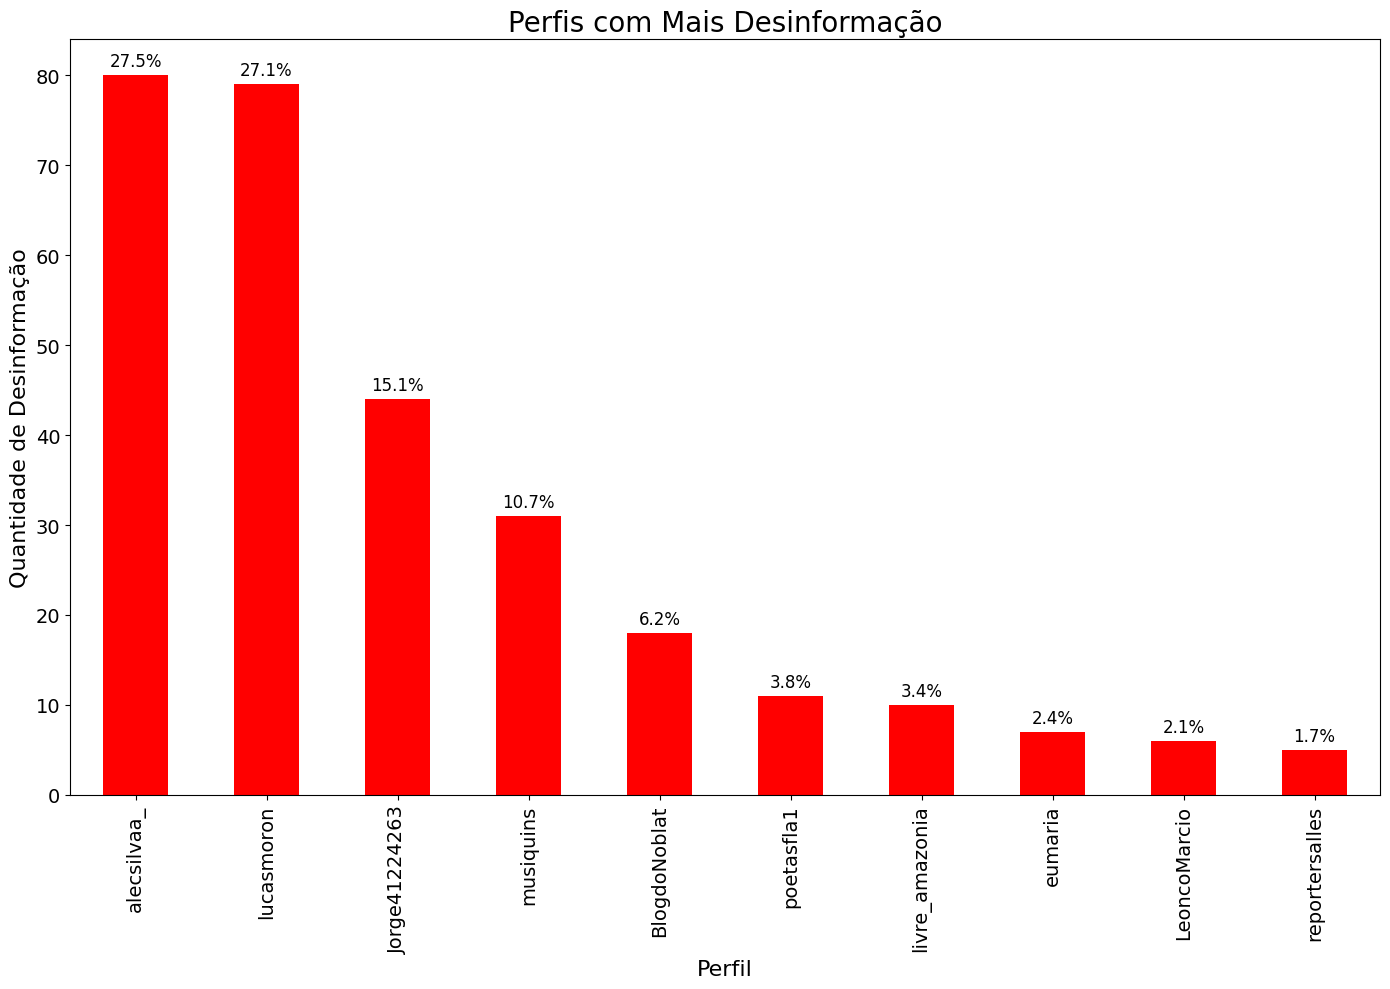

In [21]:
def main():
    # Carregar CSV de textos encontrados e desinformação
    df_cluster = pd.read_csv(caminho_cluster_1)
    
    # Carregar dados de desinformação (substitua pelo seu caminho real)
    df_desi = pd.read_excel(caminho_cluster_1_rotulado, sheet_name='Rotulados')
    
    # Criar gráfico de perfis com mais desinformação
    criar_grafico_perfis_desinformacao(df_cluster, df_desi)

if __name__ == "__main__":
    main()


In [22]:
def extrair_bigramas(textos, termos):
    # Tokenizar os textos em palavras, removendo vírgulas
    textos_tokenizados = [word_tokenize(re.sub(r'[^\w\s]', '', texto.lower())) for texto in textos]
    
    # Lista de stopwords em português
    stop_words = set(stopwords.words('portuguese'))
    
    # Inicializar lista para armazenar bigramas
    bigram_list = []
    
    # Formar bigramas com base nos textos, ignorando stopwords e palavras isoladas
    for texto_tokenizado in textos_tokenizados:
        filtered_texto = [word for word in texto_tokenizado if word not in stop_words and len(word) > 1]
        bigram_list.extend(list(bigrams(filtered_texto)))
    
    # Contar a frequência dos bigramas nos textos
    bigram_counts = Counter()
    for bigram in bigram_list:
        bigram_counts['_'.join(bigram)] += 1
    
    return bigram_counts

def criar_nuvem_de_palavras(bigram_counts):
    if len(bigram_counts) == 0:
        print("Não foram encontrados bigramas nos textos.")
        return
    
    # Obter os 150 bigramas mais frequentes
    top_bigrams = bigram_counts.most_common(150)
    
    # Preparar os dados para a nuvem de palavras
    wordcloud_dict = {bigram.replace(' ', '_'): count for bigram, count in bigram_counts.items()}
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Blues', max_words=150, prefer_horizontal=0.8)
    wordcloud.generate_from_frequencies(wordcloud_dict)
    
    # Definir estilos para os bigramas mais frequentes
    default_style = {
        'font_size': 12,
        'color': 'black',
        'regexp': r'\w[\w\s]*\w'
    }
    
    # Estilos modificados para os top bigramas
    highlighted_style = {
        **default_style,
        'font_size': 30,
        'color': 'blue',
        'font_path': None,
        'bold': True,
        'italic': True,
        'collocations': False
    }
    
    # Atualizar o estilo para os bigramas mais frequentes
    for bigram, _ in top_bigrams:
        wordcloud_dict[bigram.replace(' ', '_')] = 1
    
    # Plotar a nuvem de palavras
    plt.figure(figsize=(12, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Nuvem de Palavras com Bigramas', fontsize=16)
    plt.show()

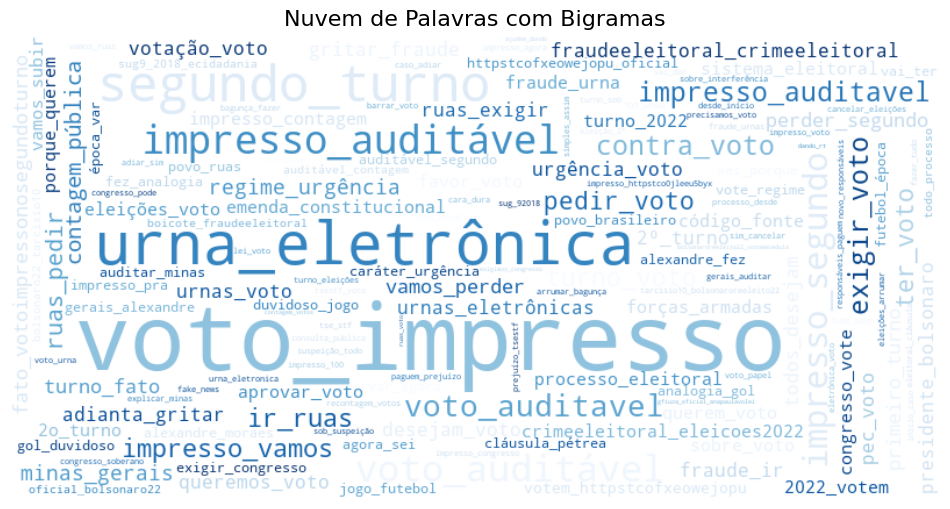

In [23]:
def main():
    # Carregar dados de desinformação
    df_desi = pd.read_excel(caminho_cluster_0_rotulado, sheet_name='Rotulados')
    
    # Extrair textos e termos
    textos = df_desi['text'].tolist()
    termos = df_desi['termo'].tolist()
    
    # Extrair bigramas dos textos e contar
    bigram_counts = extrair_bigramas(textos, termos)
    
    # Criar nuvem de palavras dos bigramas encontrados
    criar_nuvem_de_palavras(bigram_counts)

if __name__ == "__main__":
    main()

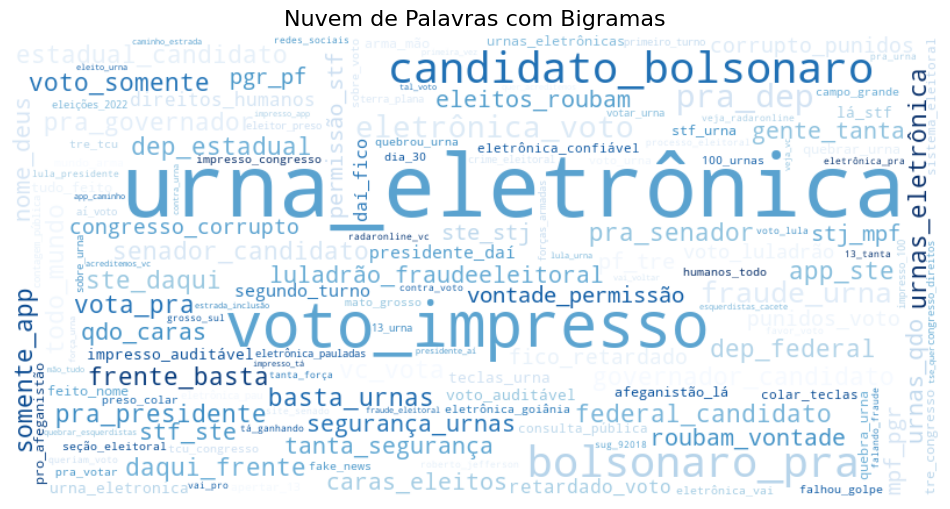

In [24]:
def main():
    # Carregar dados de desinformação
    df_desi = pd.read_excel(caminho_cluster_1_rotulado, sheet_name='Rotulados')
    
    # Extrair textos e termos
    textos = df_desi['text'].tolist()
    termos = df_desi['termo'].tolist()
    
    # Extrair bigramas dos textos e contar
    bigram_counts = extrair_bigramas(textos, termos)
    
    # Criar nuvem de palavras dos bigramas encontrados
    criar_nuvem_de_palavras(bigram_counts)

if __name__ == "__main__":
    main()